# HR Analytics: Predicting Employee Attrition

This project uses machine learning to predict employee attrition based on various workplace and personal factors. The dataset comes from IBM HR Analytics (via Kaggle).

## Objectives
- Perform EDA to understand key drivers of attrition
- Preprocess the data for modeling
- Compare Logistic Regression vs. Random Forest (with and without SMOTE)
- Evaluate model performance based on recall, precision, and ROC AUC
- Extract feature importance for HR decision-making

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv(r"C:\Users\bryan\OneDrive\Desktop\Uni stuff\Personal Projects\IBM HR Analytics\WA_Fn-UseC_-HR-Employee-Attrition.csv")

# View the first few rows
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# EDA

In [3]:
# Basic Info 
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\c")
df.info()
df.describe()

Shape: (1470, 35)

Columns:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Missing Values:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gend

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [4]:
df.duplicated().sum()

0

C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


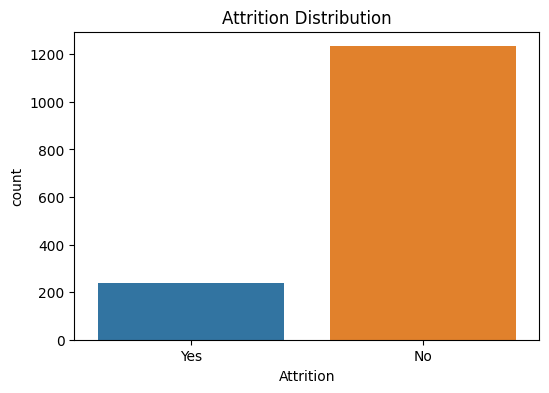

In [5]:
#Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition')
plt.title("Attrition Distribution")
plt.show()

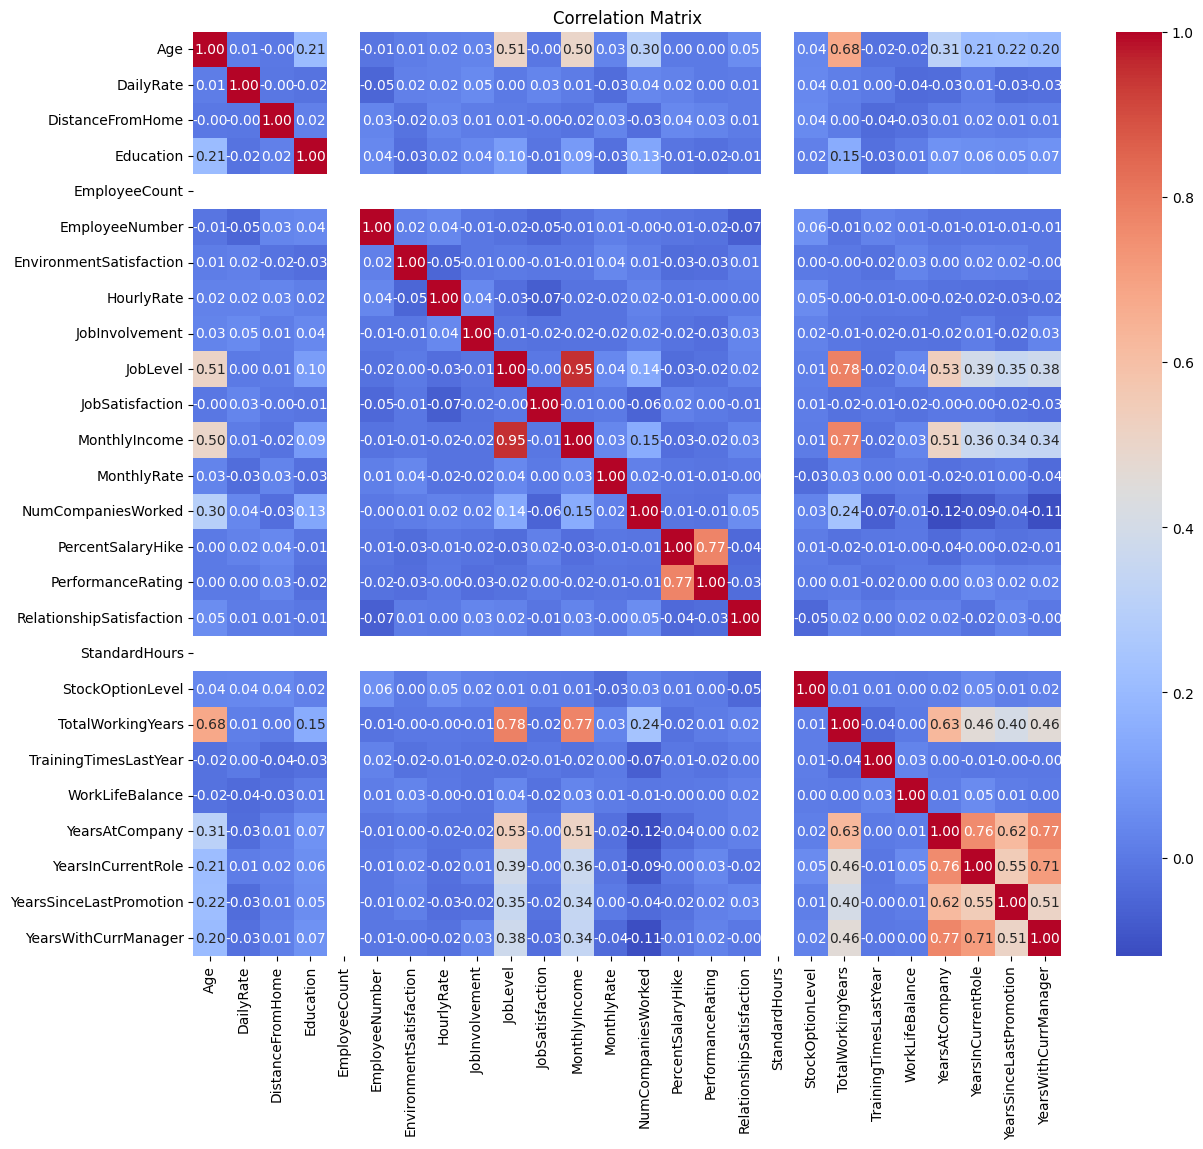

In [6]:
# Correlation Matrix 
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(14, 12))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

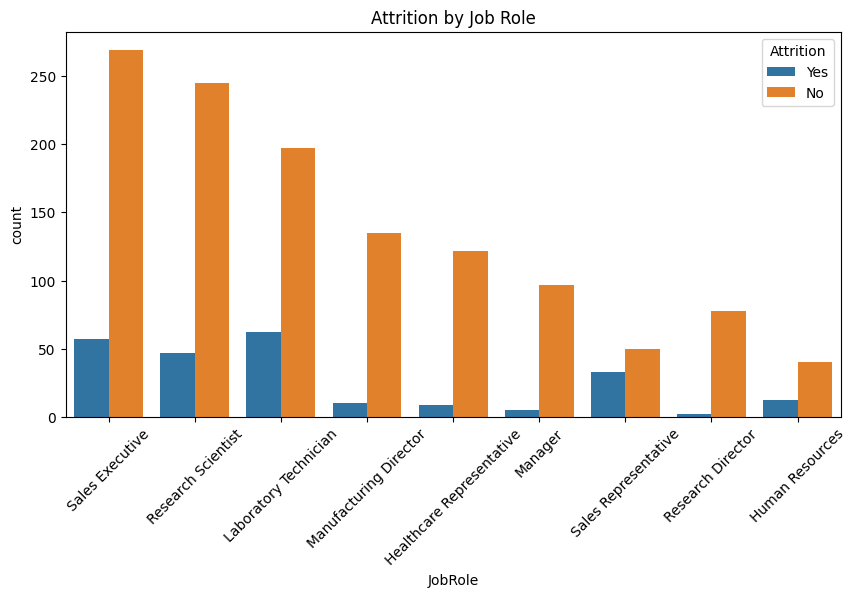

In [7]:
# Attrition by Job Role
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='JobRole', hue='Attrition')
plt.title("Attrition by Job Role")
plt.xticks(rotation=45)
plt.show()


C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

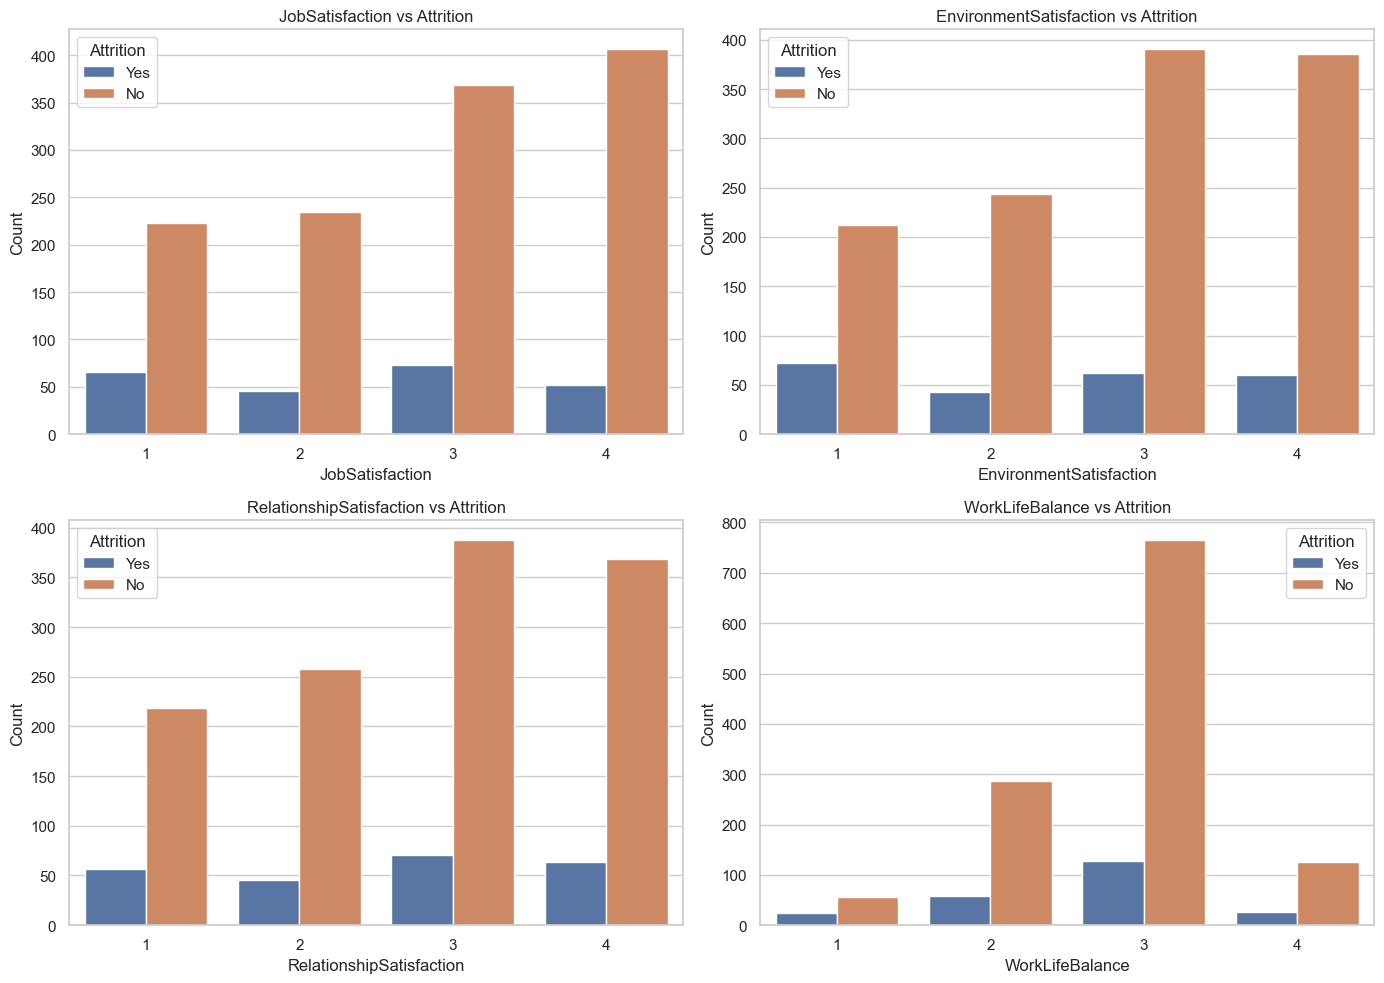

In [8]:
# Set style
sns.set(style="whitegrid")

# Satisfaction-related features
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 
                     'RelationshipSatisfaction', 'WorkLifeBalance']

# Plot
plt.figure(figsize=(14, 10))

for i, col in enumerate(satisfaction_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col, hue='Attrition')
    plt.title(f"{col} vs Attrition")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title='Attrition')

plt.tight_layout()
plt.show()

C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


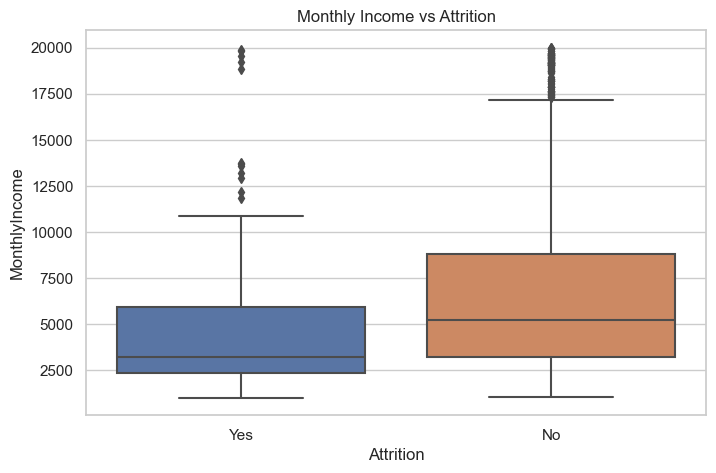

In [9]:
# --- 7. Monthly Income by Attrition ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title("Monthly Income vs Attrition")
plt.show()

From the boxplot it can be observed that the monthly income for staff who quit are lower compared to the staff members who do not quit. Across all levels in the boxplot be it the Q1, Q3, Median and Upper and Lower Quartiles thery are lower across the board. This indicates that income can be a possible contributor to the attrition rates present in the company.

C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

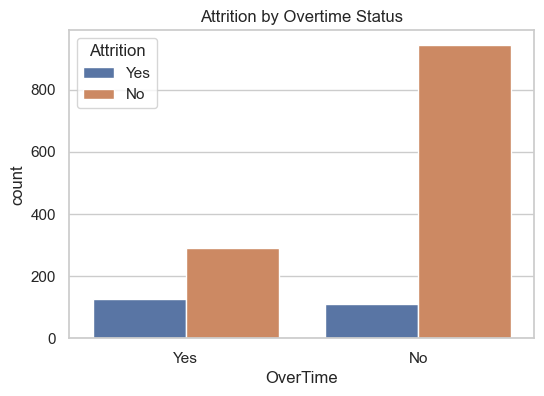

In [10]:
# Attrition vs Overtime 
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title("Attrition by Overtime Status")
plt.show()

C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


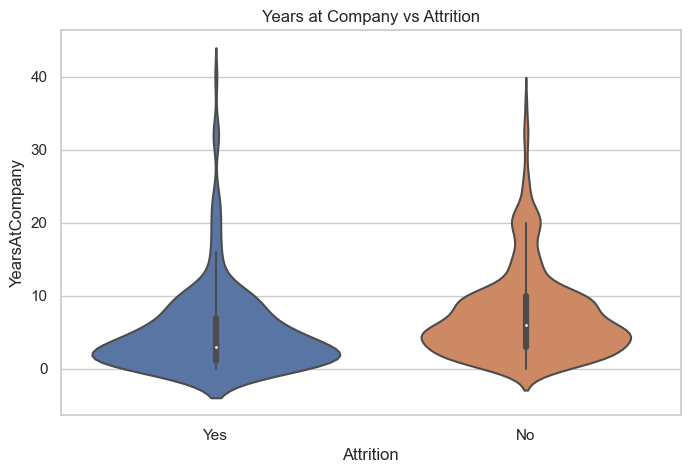

In [11]:
# Years at Company vs Attrition 
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Attrition', y='YearsAtCompany')
plt.title("Years at Company vs Attrition")
plt.show()

From the violin plot we can observe that the probability of yes occuring is larger than the probabilitity of no in the early years. This indicates that employees are more likely to leave within the first 3-5 years of joining the company, and the longer the employee stays at the company the less likely they are to leave. Therefore, early career support is crucial for reducing attrition rates.

# Preprocessing

In [12]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Drop irrelevant or constant columns
df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)

# Step 2: Encode categorical variables
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Attrition')  # Exclude target

# Use Label Encoding for simplicity
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Step 3: Encode target variable (Attrition)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Step 4: Check the final processed data
df_processed = df.copy()
df_processed.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


## Random Forests

C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


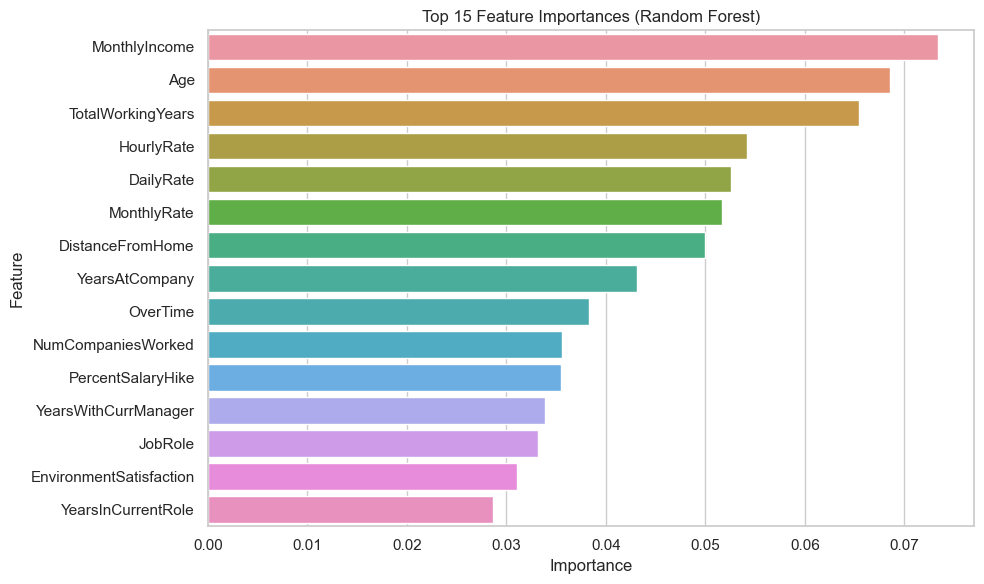

,Feature,Importance
15,MonthlyIncome,0.073336
0,Age,0.068557
23,TotalWorkingYears,0.065480
9,HourlyRate,0.054217
2,DailyRate,0.052526
16,MonthlyRate,0.051631
4,DistanceFromHome,0.049930
26,YearsAtCompany,0.043107
18,OverTime,0.038350
17,NumCompaniesWorked,0.035546


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Separate features and target
X = df_processed.drop(columns=['Attrition'])
y = df_processed['Attrition']

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3: Train a Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 4: Get feature importances
importances = rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

# Step 5: Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

importance_df


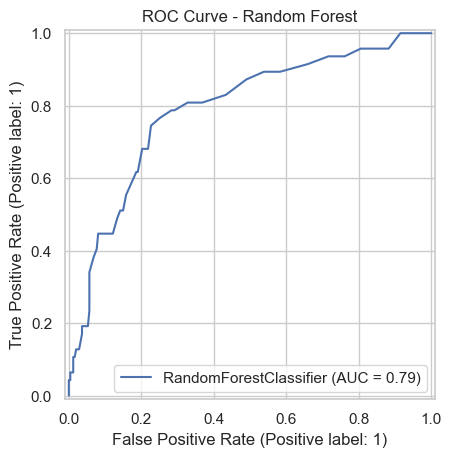

{'Accuracy': 0.844,
 'Precision': 0.545,
 'Recall': 0.128,
 'F1 Score': 0.207,
 'ROC AUC': 0.789,
 'Confusion Matrix': array([[242,   5],
        [ 41,   6]], dtype=int64),
 'Classification Report': '              precision    recall  f1-score   support\n\n           0       0.86      0.98      0.91       247\n           1       0.55      0.13      0.21        47\n\n    accuracy                           0.84       294\n   macro avg       0.70      0.55      0.56       294\nweighted avg       0.81      0.84      0.80       294\n'}

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay

# Step 1: Predict on test set
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# Step 2: Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# Step 3: Confusion matrix and ROC curve
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Plot ROC Curve
RocCurveDisplay.from_estimator(rf, X_test, y_test)

plt.title("ROC Curve - Random Forest")
plt.show()

# Show evaluation results
{
    "Accuracy": round(accuracy, 3),
    "Precision": round(precision, 3),
    "Recall": round(recall, 3),
    "F1 Score": round(f1, 3),
    "ROC AUC": round(roc_auc, 3),
    "Confusion Matrix": conf_matrix,
    "Classification Report": report
}


As the model is heavily biased due to the class imbalance as evidenced by the low recall for attrition at 0.128 which indicates that the model is only accurately predicting 13% of people who leave
The model is biased towards 'No Attrition'

In [15]:
df['Attrition'].value_counts(normalize=True) * 100


Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64

#  Random Forests with class_weight : Balanced


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
# Train a Random Forest with class_weight='balanced'
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)

# Predict on test data
y_pred_bal = rf_balanced.predict(X_test)
y_proba_bal = rf_balanced.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_bal))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))
print("ROC AUC:", roc_auc_score(y_test, y_proba_bal))



Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294

Confusion Matrix:
 [[242   5]
 [ 43   4]]
ROC AUC: 0.7573865104660178


From the classification report,  

In [17]:
#pip install imbalanced-learn

In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Train model
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_resampled, y_resampled)

# Evaluate
y_pred_smote = rf_smote.predict(X_test)
y_proba_smote = rf_smote.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_smote))
print("ROC AUC:", roc_auc_score(y_test, y_proba_smote))

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.88       247
           1       0.34      0.28      0.31        47

    accuracy                           0.80       294
   macro avg       0.60      0.59      0.59       294
weighted avg       0.78      0.80      0.79       294

Confusion Matrix:
 [[222  25]
 [ 34  13]]
ROC AUC: 0.7378327159962098


From the classification report we can see that the model performs relatively well with a ROC AUC of 0.737 indicating that it has a decent ability to distinguish between leavers and stayers. However, as we are interested in determining the employees who are actually leaving the organisation this model is insufficient. This can be seen through the low recall value which is 0.28 indicating that the model does not predict employees who are actually leaving, which causes under detection. Therefore the model is inappropriate for our business question.

# Logistic Regression 

In [19]:
# Re-import necessary module
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression with class_weight='balanced'
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

# Predict on test set
y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

# Evaluate performance
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)
roc_auc_logreg = roc_auc_score(y_test, y_proba_logreg)
conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg)
report_logreg = classification_report(y_test, y_pred_logreg)

from pprint import pprint

# Print scalar metrics
print("Model Performance (Logistic Regression)\n")
print(f"Accuracy     : {accuracy_logreg:.3f}")
print(f"Precision    : {precision_logreg:.3f}")
print(f"Recall       : {recall_logreg:.3f}")
print(f"F1 Score     : {f1_logreg:.3f}")
print(f"ROC AUC      : {roc_auc_logreg:.3f}\n")

# Print Confusion Matrix
print("Confusion Matrix:")
print(conf_matrix_logreg, "\n")

# Print Classification Report
print("Classification Report:")
print(report_logreg)


Model Performance (Logistic Regression)

Accuracy     : 0.650
Precision    : 0.270
Recall       : 0.702
F1 Score     : 0.391
ROC AUC      : 0.744

Confusion Matrix:
[[158  89]
 [ 14  33]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.64      0.75       247
           1       0.27      0.70      0.39        47

    accuracy                           0.65       294
   macro avg       0.59      0.67      0.57       294
weighted avg       0.81      0.65      0.70       294



C:\Users\bryan\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


From the model performance we can conclude that the model's performance is acceptable for the use of early intervention as it can accurately identify 70% of leavers. However, the model does not have a high precision rate indicating that the model tends to over predict. 
However, this is acceptable in an HR setting as it is preferable to be overly cautious than to under detect.
Therefore, HR can then use this model for proactive interventions such as sceheduling interviews with flagged employees, as well as monitor satisfaction levels and promotion timeines

In [20]:
# Analyze coefficients
feature_names = X.columns
coefficients = logreg.coef_[0]
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds_Ratio': np.exp(coefficients)
}).sort_values(by='Coefficient', ascending=False)

coef_df.head(10)  # Top features increasing attrition

,Feature,Coefficient,Odds_Ratio
18,OverTime,0.188364,1.207273
17,NumCompaniesWorked,0.183876,1.201867
14,MaritalStatus,0.172006,1.187684
28,YearsSinceLastPromotion,0.145518,1.156639
3,Department,0.077512,1.080595
20,PerformanceRating,0.063930,1.066018
1,BusinessTravel,0.061623,1.063562
4,DistanceFromHome,0.053395,1.054846
12,JobRole,0.045308,1.046350
26,YearsAtCompany,0.041791,1.042677


In [21]:
coef_df.head(
)

,Feature,Coefficient,Odds_Ratio
18,OverTime,0.188364,1.207273
17,NumCompaniesWorked,0.183876,1.201867
14,MaritalStatus,0.172006,1.187684
28,YearsSinceLastPromotion,0.145518,1.156639
3,Department,0.077512,1.080595


C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


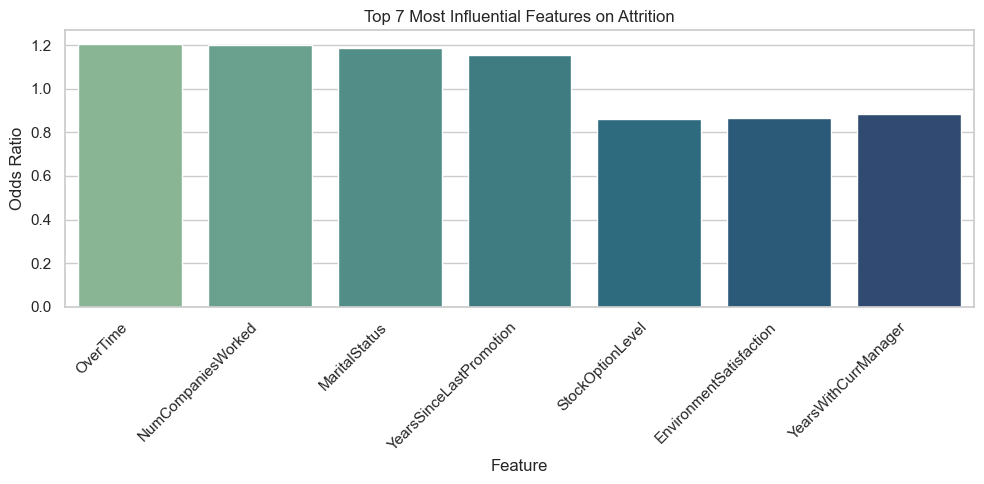

In [22]:
# Sort by impact (Odds Ratio deviation from 1)
coef_df['Impact'] = abs(coef_df['Odds_Ratio'] - 1)
top_features = coef_df.sort_values(by='Impact', ascending=False).head(7)


# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_features, x='Feature', y='Odds_Ratio', palette='crest')
plt.xticks(rotation=45, ha='right')
plt.title('Top 7 Most Influential Features on Attrition')
plt.xlabel('Feature')
plt.ylabel('Odds Ratio')
plt.tight_layout()
plt.show()

In [23]:
# Coefficients
feature_names = X.columns
coefficients = logreg.coef_[0]
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds_Ratio': np.exp(coefficients)
}).sort_values(by='Coefficient')

# Show bottom 10 features (negatively associated with attrition)
coef_df.head(10)

,Feature,Coefficient,Odds_Ratio
22,StockOptionLevel,-0.151395,0.859508
7,EnvironmentSatisfaction,-0.146074,0.864094
29,YearsWithCurrManager,-0.123667,0.883674
13,JobSatisfaction,-0.114917,0.891440
27,YearsInCurrentRole,-0.098760,0.905960
10,JobInvolvement,-0.085086,0.918433
23,TotalWorkingYears,-0.057897,0.943747
21,RelationshipSatisfaction,-0.038366,0.962361
25,WorkLifeBalance,-0.034917,0.965686
24,TrainingTimesLastYear,-0.026003,0.974332


C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bryan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


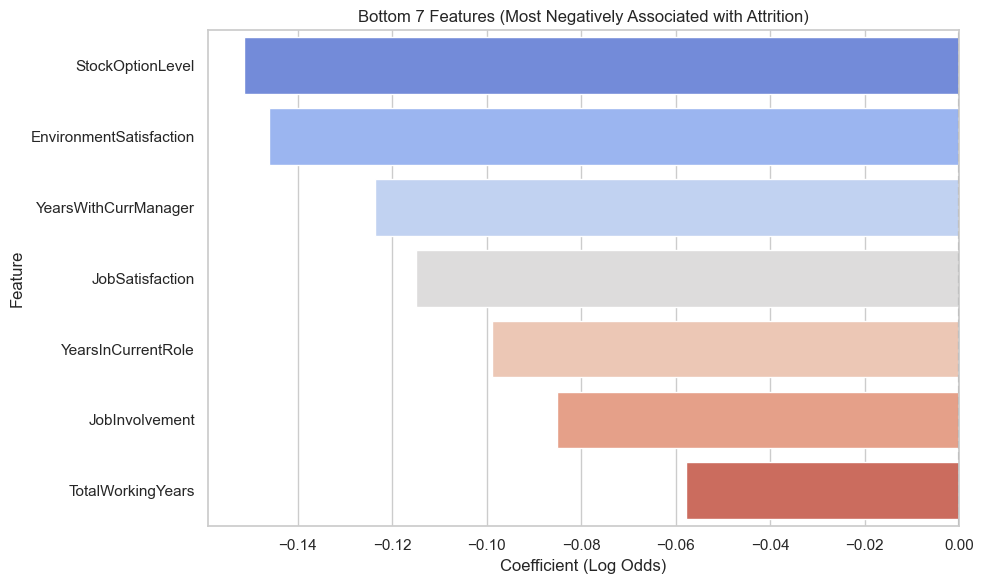

In [24]:

# Get bottom 10 features by coefficient
bottom_coef = coef_df.head(7)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=bottom_coef, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Bottom 7 Features (Most Negatively Associated with Attrition)')
plt.xlabel('Coefficient (Log Odds)')
plt.ylabel('Feature')
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

# Final Conclusions & Recommendations

This project uses machine learning to predict employee attrition rates for HR using employee data from IBM. After the completeion of the product the result show:
## Key Findings
- **OverTime**, **NumCompaniesWorked**, and **YearsSinceLastPromotion** are strong predictors of attrition.
- Features like **StockOptionLevel**, **EnvironmentSatisfaction**, and **YearsWithCurrManager** are linked to retention.
- Logistic Regression achieved **high recall (~70%)**, making it the best model for identifying employees at risk of leaving.
- Random Forest (with SMOTE) had higher overall accuracy but lower recall.

## HR Recommendations
- Create focused retention efforts on **New Employees**, especially employees who are in their **first three years** in the company.
- Monitor **overtime workloads**, and **promotion timelines**
- HR can utilise this model predictions to stage interviews with employees who are flagged 
- HR can also consider employing this model as a dashboard to proactively flag at-risk employees/



## 📁 File Structure
```
HR Analytics.ipynb       # Main notebook
README.md                # Project summary
data/                    # Folder for input CSV

```

